# QwenVL vs MemER localization comparison

This notebook compares coordinate predictions from the two `SwingXtimes_epN.log` files. MemER is used as the reference, so the result is a **difference between predictors**, not an error against ground truth.

Coordinate distance is defined as:

`sqrt((QwenVL_y - MemER_y)^2 + (QwenVL_x - MemER_x)^2)`

## 1. Configuration

Change `EPISODE` to select the episode. `SAMPLE` can be `first`, `last`, or `mean` for repeated predictions within each semantic stage.

In [52]:
from pathlib import Path

EPISODE = 12
SAMPLE = "first"  # "first", "last", or "mean"
RUNS_DIR = Path("../runs")  # Correct when the notebook runs from user_code/
# Set either override to a Path(...) if your logs are stored elsewhere.
QWEN_LOG_OVERRIDE = None
MEMER_LOG_OVERRIDE = None

## 2. Imports and parsing helpers

In [53]:
import re

import matplotlib.pyplot as plt
import pandas as pd

BOX_RE = re.compile(
    r"<\|box_start\|>\s*\(\s*(\d+)\s*,\s*(\d+)\s*\)\s*<\|box_end\|>"
)
RESPONSE_RE = re.compile(r"^Response:\s*(.+)$")
STAGE_ORDER = [
    "pickup-cube",
    "right-target-1",
    "left-target-1",
    "right-target-2",
    "left-target-2",
    "press-button",
]

def stage_from_text(text):
    normalized = " ".join(text.lower().split())
    if re.search(r"\bpick up the .+? cube\b", normalized):
        return "pickup-cube"
    if "right-side target" in normalized:
        return "right-target-2" if "second time" in normalized else "right-target-1"
    if "left-side target" in normalized:
        return "left-target-2" if "second time" in normalized else "left-target-1"
    if "press the button" in normalized:
        return "press-button"
    return None

def parse_log(path):
    predictions = []
    with path.open("r", encoding="utf-8", errors="replace") as handle:
        for line_number, line in enumerate(handle, start=1):
            response_match = RESPONSE_RE.match(line.strip())
            if not response_match:
                continue
            response = response_match.group(1)
            box_match = BOX_RE.search(response)
            stage = stage_from_text(response)
            if box_match is None or stage is None:
                continue
            predictions.append({
                "stage": stage,
                "y": int(box_match.group(1)),
                "x": int(box_match.group(2)),
                "line_number": line_number,
                "response": response,
            })
    if not predictions:
        raise ValueError(f"No coordinate-bearing SwingXtimes responses found in {path}")
    return pd.DataFrame(predictions)

def select_by_stage(frame, sample):
    if sample == "first":
        return frame.groupby("stage", sort=False, as_index=False).first()
    if sample == "last":
        return frame.groupby("stage", sort=False, as_index=False).last()
    if sample == "mean":
        result = frame.groupby("stage", sort=False, as_index=False)[["y", "x"]].mean()
        result[["y", "x"]] = result[["y", "x"]].round().astype(int)
        return result
    raise ValueError(f"Unknown SAMPLE value: {sample}")

## 3. Locate and parse the two logs

In [54]:
root = (
    RUNS_DIR / "evaluation" / "symbolic-grounded-subgoal"
    / "ckpt79999" / "seed7"
)
qwen_log = QWEN_LOG_OVERRIDE or (
    root / "qwenvl" / "SwingXtimes" / "logs" / f"SwingXtimes_ep{EPISODE}.log"
)
memer_log = MEMER_LOG_OVERRIDE or (
    root / "memer" / "SwingXtimes" / "logs" / f"SwingXtimes_ep{EPISODE}.log"
)

assert qwen_log.is_file(), f"QwenVL log not found: {qwen_log.resolve()}"
assert memer_log.is_file(), f"MemER log not found: {memer_log.resolve()}"

print("QwenVL:", qwen_log)
print("MemER: ", memer_log)

qwen_all = parse_log(qwen_log)
memer_all = parse_log(memer_log)
display(qwen_all.head())
display(memer_all.head())

QwenVL: ../runs/evaluation/symbolic-grounded-subgoal/ckpt79999/seed7/qwenvl/SwingXtimes/logs/SwingXtimes_ep12.log
MemER:  ../runs/evaluation/symbolic-grounded-subgoal/ckpt79999/seed7/memer/SwingXtimes/logs/SwingXtimes_ep12.log


,stage,y,x,line_number,response
0,pickup-cube,223,551,24,"pick up the red cube at <|box_start|>(223,551)..."
1,pickup-cube,223,551,44,"pick up the red cube at <|box_start|>(223,551)..."
2,pickup-cube,223,551,64,"pick up the red cube at <|box_start|>(223,551)..."
3,pickup-cube,223,551,84,"pick up the red cube at <|box_start|>(223,551)..."
4,pickup-cube,223,551,104,"pick up the red cube at <|box_start|>(223,551)..."


,stage,y,x,line_number,response
0,pickup-cube,230,562,12,"{""current_subtask"": ""pick up the red cube at <..."
1,pickup-cube,230,562,28,"{""current_subtask"":""pick up the red cube at <|..."
2,pickup-cube,230,562,44,"{""current_subtask"":""pick up the red cube at <|..."
3,pickup-cube,230,562,60,"{""current_subtask"":""pick up the red cube at <|..."
4,pickup-cube,230,562,76,"{""current_subtask"":""pick up the red cube at <|..."


## 4. Align semantic stages and calculate differences

The logs cannot safely be aligned by response index because QwenVL and MemER may switch stages at different times. They are therefore aligned by semantic stage.

In [55]:
qwen = select_by_stage(qwen_all, SAMPLE).rename(
    columns={"y": "qwen_y", "x": "qwen_x"}
)
memer = select_by_stage(memer_all, SAMPLE).rename(
    columns={"y": "memer_y", "x": "memer_x"}
)
comparison = qwen[["stage", "qwen_y", "qwen_x"]].merge(
    memer[["stage", "memer_y", "memer_x"]], on="stage", how="inner"
)
comparison["stage"] = pd.Categorical(
    comparison["stage"], categories=STAGE_ORDER, ordered=True
)
comparison = comparison.sort_values("stage").reset_index(drop=True)
comparison["delta_y"] = comparison["qwen_y"] - comparison["memer_y"]
comparison["delta_x"] = comparison["qwen_x"] - comparison["memer_x"]
comparison["distance"] = (
    comparison["delta_y"] ** 2 + comparison["delta_x"] ** 2
).pow(0.5)
comparison

,stage,qwen_y,qwen_x,memer_y,memer_x,delta_y,delta_x,distance
0,pickup-cube,223,551,230,562,-7,-11,13.038405
1,right-target-1,309,246,324,258,-15,-12,19.209373
2,left-target-1,332,707,344,723,-12,-16,20.000000
3,right-target-2,309,242,324,254,-15,-12,19.209373
4,left-target-2,328,703,344,723,-16,-20,25.612497
5,press-button,254,445,262,461,-8,-16,17.888544


## 5. Plot results

- **Horizontal axis:** grounded-subgoal stages in execution order.
- **Vertical axis:** Euclidean distance between the QwenVL and MemER predicted coordinates, measured directly in Qwen's 0-1000 coordinate units.

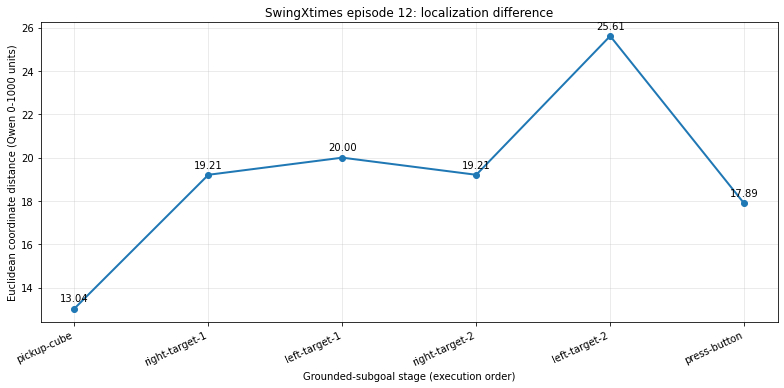

In [56]:
fig, ax = plt.subplots(figsize=(11, 5.5))
values = comparison["distance"].to_numpy()
labels = comparison["stage"].astype(str).tolist()
ax.plot(range(len(comparison)), values, marker="o", linewidth=2)
ax.set_xticks(range(len(comparison)))
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("Euclidean coordinate distance (Qwen 0-1000 units)")
ax.set_xlabel("Grounded-subgoal stage (execution order)")
ax.set_title(f"SwingXtimes episode {EPISODE}: localization difference")
ax.grid(True, alpha=0.3)
for index, value in enumerate(values):
    ax.annotate(
        f"{value:.2f}", (index, value), xytext=(0, 7),
        textcoords="offset points", ha="center"
    )
fig.tight_layout()
plt.show()

## Interpretation

An increasing curve means the two predictors diverge more in later stages. It does **not by itself prove** that inaccurate coordinates in QwenVL's prompt caused accumulated error. A ground-truth coordinate series is needed to determine whether QwenVL gets worse, MemER changes, or both.